In [31]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [32]:
df = pd.read_csv("../../../../Data/Housing_Data.csv",usecols=['GarageQual', 'FireplaceQu','SalePrice'])
df

,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000
...,...,...,...
1455,TA,TA,175000
1456,TA,TA,210000
1457,Gd,TA,266500
1458,NaN,TA,142125


In [33]:
df.isnull().mean() * 100

FireplaceQu    47.260274
GarageQual      5.547945
SalePrice       0.000000
dtype: float64

In [34]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df.iloc[:,:-1],df.iloc[:,-1], test_size=0.2, random_state=42)
X_train

,FireplaceQu,GarageQual
254,NaN,TA
1066,TA,TA
638,NaN,NaN
799,TA,TA
380,Gd,TA
...,...,...
1095,Gd,TA
1130,TA,TA
1294,NaN,TA
860,Gd,TA


In [44]:
from sklearn.impute import SimpleImputer
imp = SimpleImputer(strategy='most_frequent')
X_train_imp = imp.fit_transform(X_train)
X_test_imp = imp.transform(X_test)

# Check Distribution
## 1) Check barplot

<Axes: xlabel='GarageQual'>

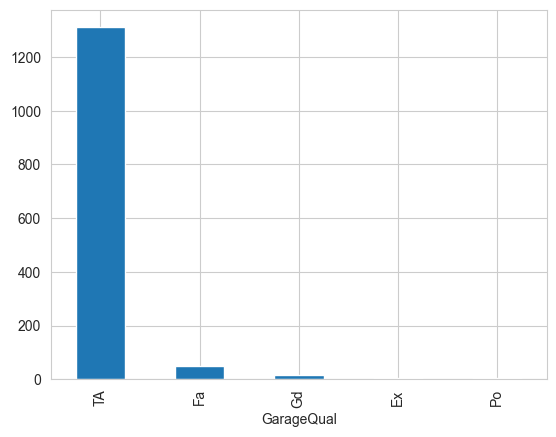

In [35]:
df['GarageQual'].value_counts().plot(kind='bar')

<Axes: xlabel='FireplaceQu'>

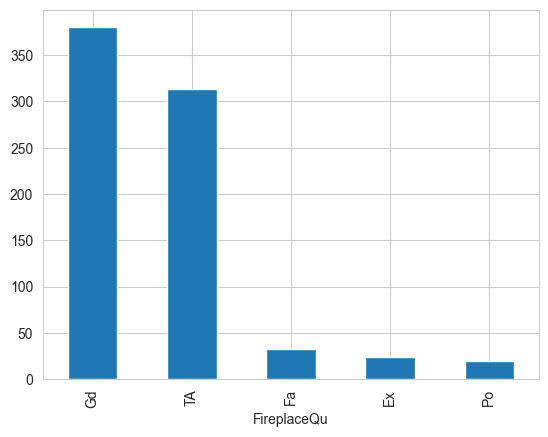

In [36]:
df['FireplaceQu'].value_counts().plot(kind='bar')

## 2) check most-frequent value and null value

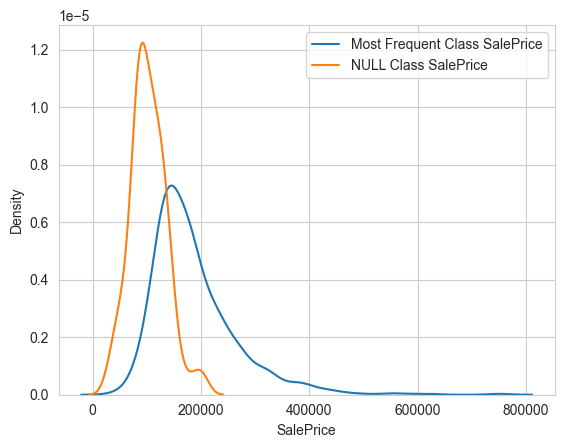

In [37]:
sns.kdeplot(data=df[df['GarageQual'] == 'TA'],x='SalePrice', label='Most Frequent Class SalePrice')
sns.kdeplot(data=df[df['GarageQual'].isnull()],x='SalePrice', label='NULL Class SalePrice')

plt.legend()


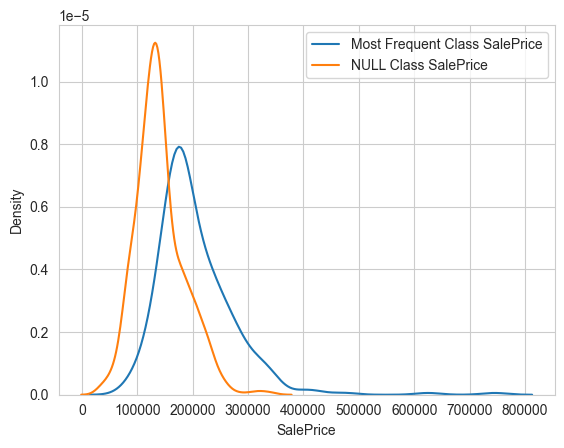

In [38]:
sns.kdeplot(data=df[df['FireplaceQu'] == 'TA'],x='SalePrice', label='Most Frequent Class SalePrice')
sns.kdeplot(data=df[df['FireplaceQu'].isnull()],x='SalePrice', label='NULL Class SalePrice')

plt.legend()


# After filling



In [39]:
imputed_data = pd.DataFrame()

imputed_data['GarageQual'] = df['GarageQual']
imputed_data['GarageQual_FillNull'] = df['GarageQual'].fillna(df['GarageQual'].mode)

imputed_data['FireplaceQu'] = df['FireplaceQu']
imputed_data['FireplaceQu_FillNull'] = df['FireplaceQu'].fillna(df['FireplaceQu'].mode)

imputed_data['SalePrice'] = df['SalePrice']


## 1. Check barplot

<Axes: xlabel='GarageQual_FillNull'>

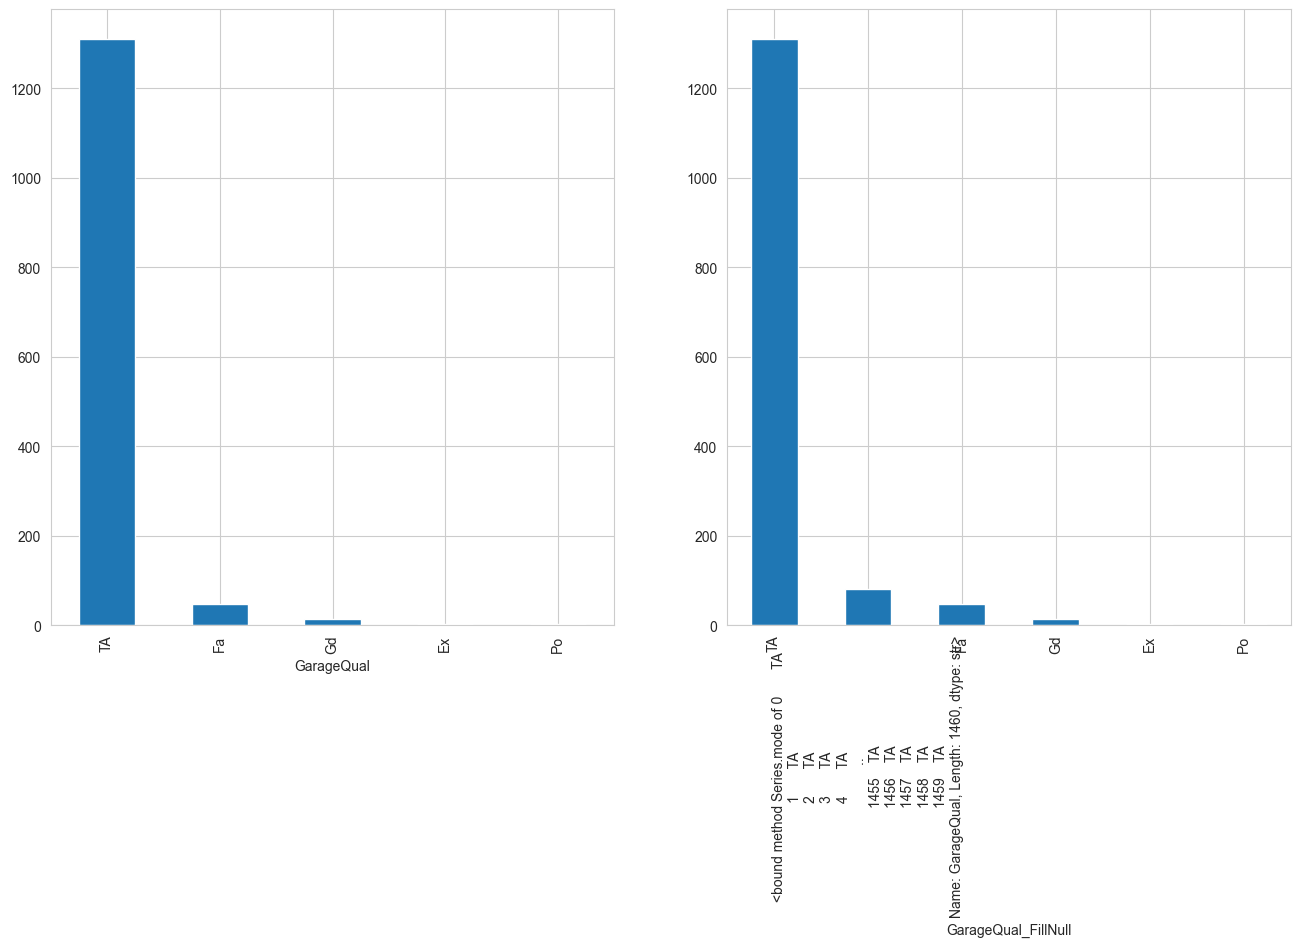

In [40]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(16,8))
imputed_data['GarageQual'].value_counts().plot(kind='bar', ax=ax[0])
imputed_data['GarageQual_FillNull'].value_counts().plot(kind='bar', ax=ax[1])

<Axes: xlabel='FireplaceQu_FillNull'>

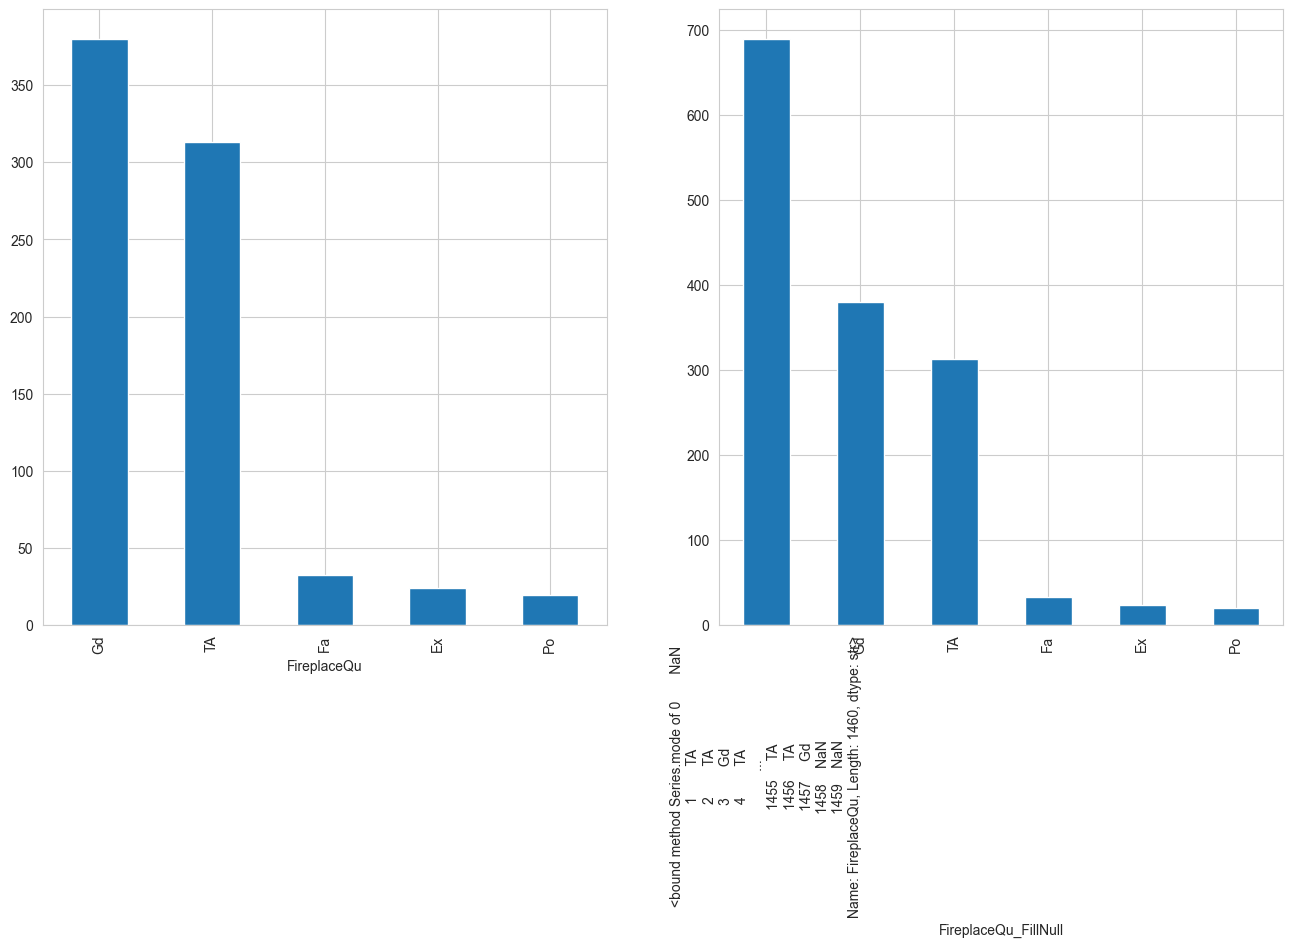

In [41]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(16,8))
imputed_data['FireplaceQu'].value_counts().plot(kind='bar', ax=ax[0])
imputed_data['FireplaceQu_FillNull'].value_counts().plot(kind='bar', ax=ax[1])

## 2. Check distribution

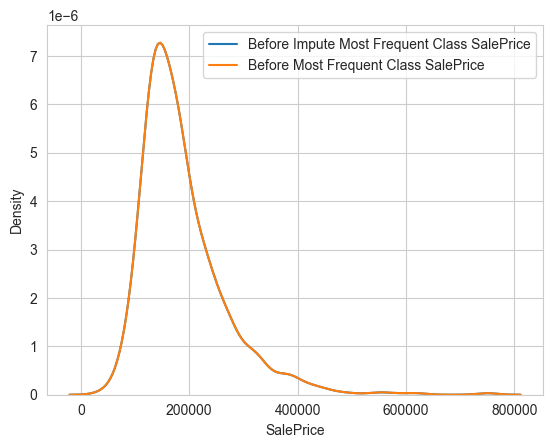

In [42]:
sns.kdeplot(data=imputed_data[imputed_data['GarageQual'] == 'TA'],x='SalePrice', label='Before Impute Most Frequent Class SalePrice')
sns.kdeplot(data=imputed_data[imputed_data['GarageQual_FillNull'] == 'TA'],x='SalePrice', label='Before Most Frequent Class SalePrice')

plt.legend()


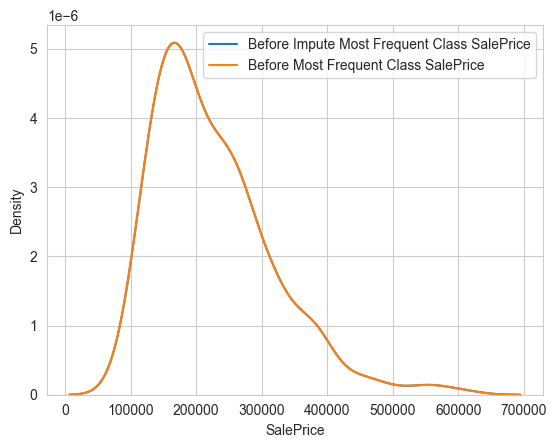

In [43]:
sns.kdeplot(data=imputed_data[imputed_data['FireplaceQu'] == 'Gd'],x='SalePrice', label='Before Impute Most Frequent Class SalePrice')
sns.kdeplot(data=imputed_data[imputed_data['FireplaceQu_FillNull'] == 'Gd'],x='SalePrice', label='Before Most Frequent Class SalePrice')

plt.legend()
